C:\Users\Jacob\AppData\Local\Temp\ipykernel_11624\3052705558.py:96: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0
C:\Users\Jacob\AppData\Local\Temp\ipykernel_11624\3052705558.py:96: SettingWithCopyWarning: modifications to a method of a datetimelike object are not supported and are discarded. Change values on the original.
  dt_s.iloc[0] = 0



Measured reference capacity from discharge test
--------------------------------------------------
Measured usable capacity: 2.1288 Ah
Measured usable energy:   8.0464 Wh
Nominal capacity:         2.0000 Ah
Nominal energy:           7.4000 Wh

Charge dataset
--------------------------------------------------
Charge duration:          8.585 h
Integrated charge:        2.1480 Ah
Integrated charge energy: 9.1382 Wh
Final SoC from Ah:        100.90 %
Final SoC from Wh:        110.00 %

Discharge dataset
--------------------------------------------------
Discharge duration:          13.150 h
Integrated discharged Ah:    2.1288 Ah
Integrated discharged Wh:    8.0464 Wh
Final SoC from Ah:           0.00 %
Final SoC from Wh:           0.00 %


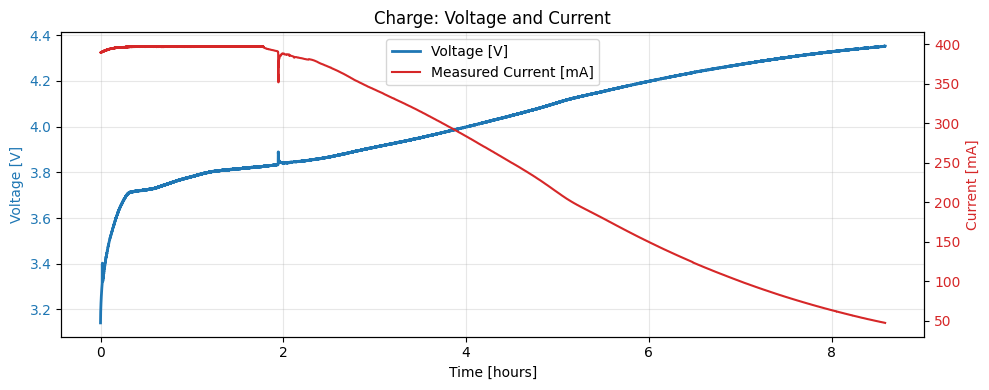

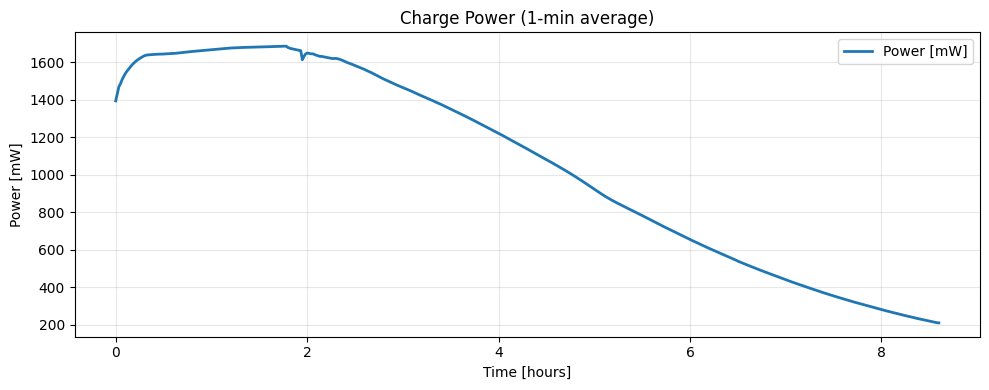

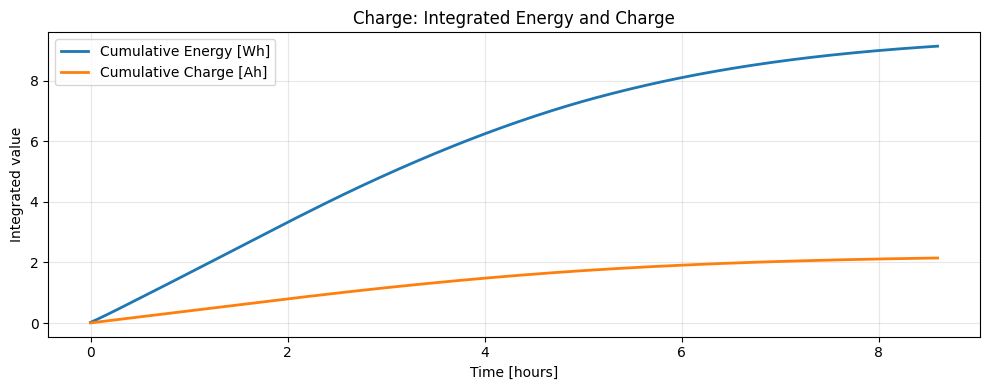

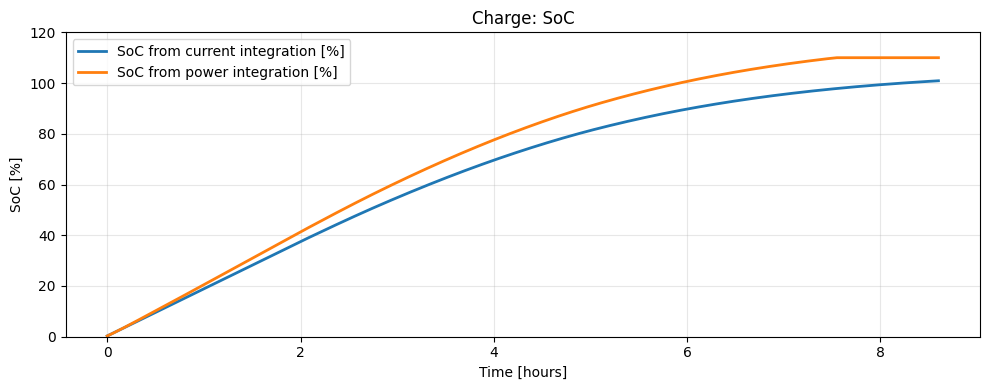

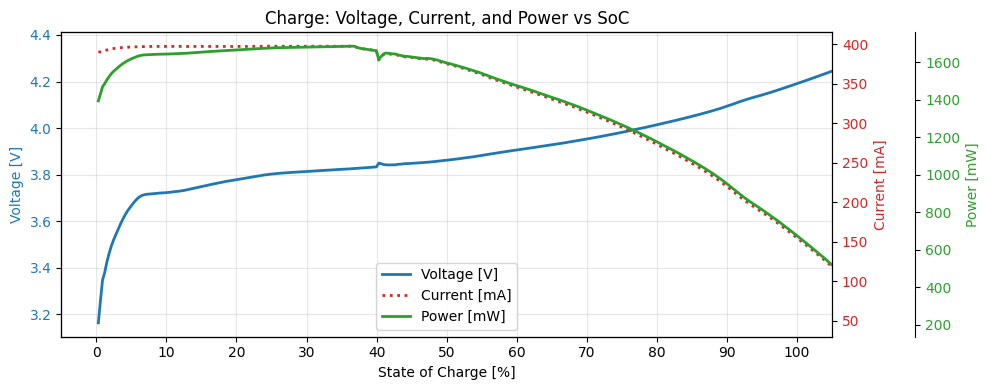

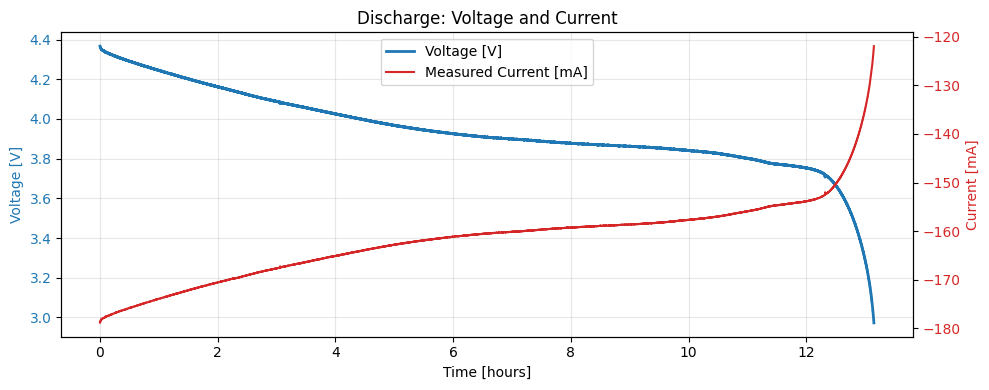

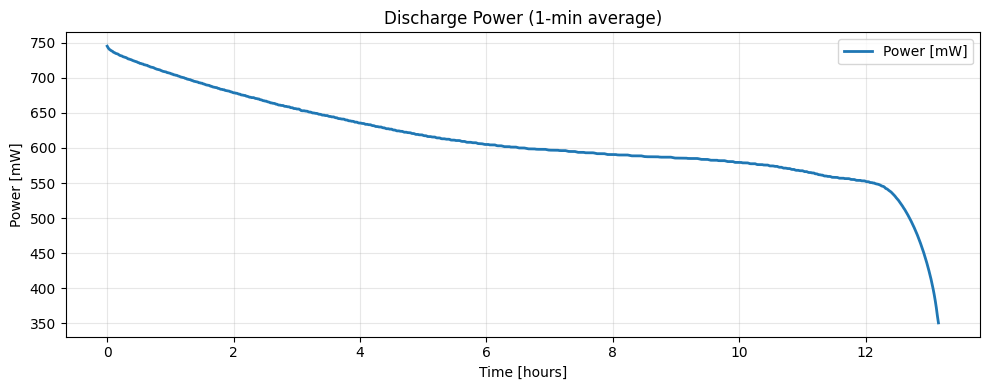

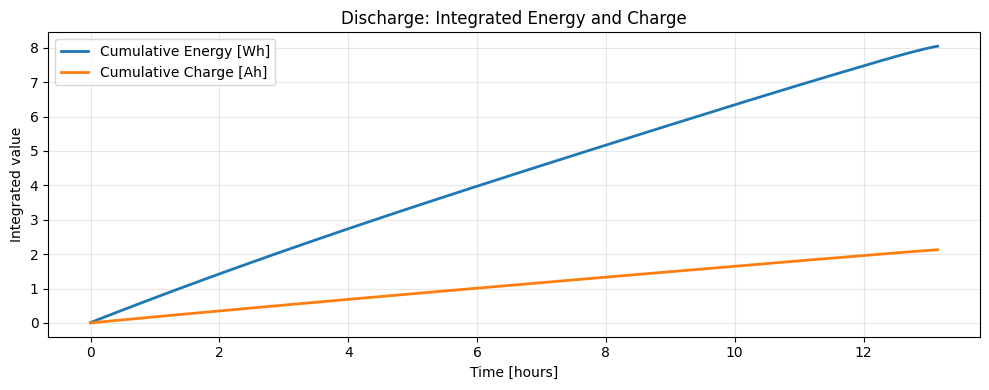

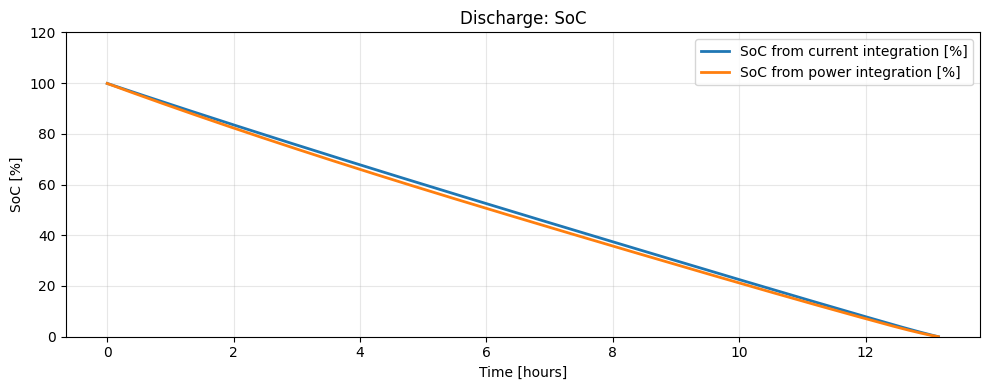

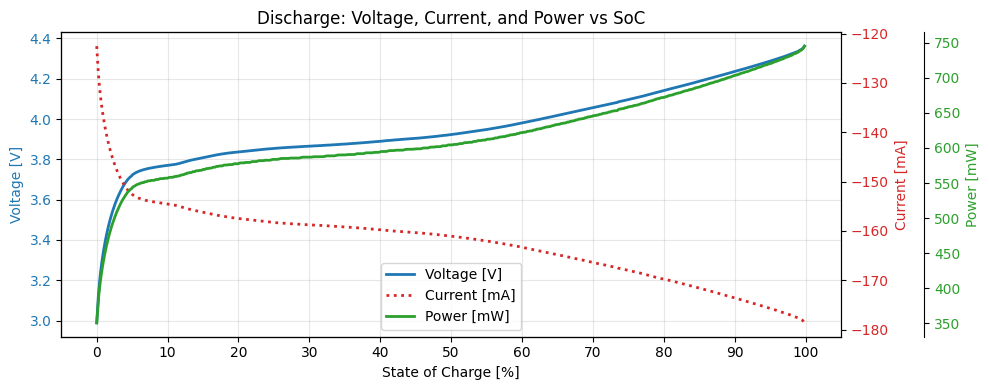

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ----------------------------
# Settings
# ----------------------------
charge_file = Path("BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv")
discharge_file = Path("BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv")

resample_interval = "1min"
charge_threshold_mA = 10.0
discharge_threshold_mA = -10.0

# Optional nominal values for comparison only
battery_nominal_Ah = 2.0
battery_nominal_Wh = 7.4


# ----------------------------
# Helpers
# ----------------------------
def load_and_clean(csv_file):
    df = pd.read_csv(csv_file)

    df["pc_time"] = pd.to_datetime(df["pc_time"], errors="coerce")
    df = df.dropna(subset=["pc_time"]).copy()
    df = df.sort_values("pc_time").reset_index(drop=True)
    df = df.drop_duplicates(subset="pc_time", keep="first").copy()

    numeric_cols = [
        "elapsed_s", "bus_V", "current_mA", "power_mW", "shunt_mV",
        "voltage_corrected_V", "soc_voltage_percent", "soc_percent"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "mode" in df.columns:
        df["mode"] = df["mode"].astype(str).str.strip().str.upper()

    df = df.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    return df


def extract_active_block(df, target_mode):
    if "mode" in df.columns and (df["mode"] == target_mode).any():
        is_active = df["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active = df["current_mA"] > charge_threshold_mA
        elif target_mode == "DISCHARGE":
            is_active = df["current_mA"] < discharge_threshold_mA
        else:
            raise ValueError(f"Unsupported target_mode: {target_mode}")

    if not is_active.any():
        raise ValueError(f"No rows found for mode {target_mode}")

    start_idx = is_active.idxmax()
    df_after_start = df.loc[start_idx:].copy()

    if "mode" in df.columns and (df_after_start["mode"] == target_mode).any():
        is_active_after = df_after_start["mode"] == target_mode
    else:
        if target_mode == "CHARGE":
            is_active_after = df_after_start["current_mA"] > charge_threshold_mA
        else:
            is_active_after = df_after_start["current_mA"] < discharge_threshold_mA

    stop_candidates = df_after_start.index[~is_active_after]

    if len(stop_candidates) > 0:
        stop_idx = stop_candidates[0]
        df_block = df.loc[start_idx:stop_idx - 1].copy()
    else:
        df_block = df.loc[start_idx:].copy()

    if df_block.empty:
        raise ValueError(f"Filtered dataframe is empty for mode {target_mode}")

    return df_block


def prepare_block(df_block, mode_name, resample_interval="1min"):
    df_plot = df_block.copy()

    # Relative time
    df_plot["t_hours"] = (
        df_plot["pc_time"] - df_plot["pc_time"].iloc[0]
    ).dt.total_seconds() / 3600.0

    # dt
    dt_s = df_plot["pc_time"].diff().dt.total_seconds()
    dt_s.iloc[0] = 0
    dt_s = dt_s.clip(lower=0, upper=10)
    df_plot["dt_s"] = dt_s
    df_plot["dt_h"] = df_plot["dt_s"] / 3600.0

    # Active current / power as positive quantities
    if mode_name == "CHARGE":
        df_plot["active_current_mA"] = df_plot["current_mA"].clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].clip(lower=0)
    elif mode_name == "DISCHARGE":
        df_plot["active_current_mA"] = (-df_plot["current_mA"]).clip(lower=0)
        df_plot["active_power_mW"] = df_plot["power_mW"].abs()
    else:
        raise ValueError("mode_name must be CHARGE or DISCHARGE")

    df_plot["active_current_A"] = df_plot["active_current_mA"] / 1000.0
    df_plot["active_power_W"] = df_plot["active_power_mW"] / 1000.0

    # Incremental Ah / Wh
    df_plot["dQ_Ah"] = df_plot["active_current_A"] * df_plot["dt_h"]
    df_plot["dE_Wh"] = df_plot["active_power_W"] * df_plot["dt_h"]

    df_plot["cum_Ah"] = df_plot["dQ_Ah"].cumsum()
    df_plot["cum_Wh"] = df_plot["dE_Wh"].cumsum()

    # Resample
    df_min = df_plot.set_index("pc_time").resample(resample_interval).mean(numeric_only=True)
    df_min = df_min.dropna(subset=["bus_V", "current_mA", "power_mW"]).copy()
    df_min["t_hours"] = (df_min.index - df_min.index[0]).total_seconds() / 3600.0

    dt_resample_h = pd.to_timedelta(resample_interval).total_seconds() / 3600.0

    if mode_name == "CHARGE":
        df_min["active_current_mA"] = df_min["current_mA"].clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].clip(lower=0)
    else:
        df_min["active_current_mA"] = (-df_min["current_mA"]).clip(lower=0)
        df_min["active_power_mW"] = df_min["power_mW"].abs()

    df_min["active_current_A"] = df_min["active_current_mA"] / 1000.0
    df_min["active_power_W"] = df_min["active_power_mW"] / 1000.0

    df_min["dQ_Ah"] = df_min["active_current_A"] * dt_resample_h
    df_min["dE_Wh"] = df_min["active_power_W"] * dt_resample_h

    df_min["cum_Ah"] = df_min["dQ_Ah"].cumsum()
    df_min["cum_Wh"] = df_min["dE_Wh"].cumsum()

    return df_plot, df_min


def add_soc_columns(df_min, mode_name, reference_Ah, reference_Wh):
    df_min = df_min.copy()

    # Coulomb-counted SoC
    if mode_name == "CHARGE":
        df_min["soc_from_Ah"] = 100 * df_min["cum_Ah"] / reference_Ah
        df_min["soc_from_Wh"] = 100 * df_min["cum_Wh"] / reference_Wh
    else:
        df_min["soc_from_Ah"] = 100 * (1 - df_min["cum_Ah"] / reference_Ah)
        df_min["soc_from_Wh"] = 100 * (1 - df_min["cum_Wh"] / reference_Wh)

    df_min["soc_from_Ah"] = df_min["soc_from_Ah"].clip(0, 110)
    df_min["soc_from_Wh"] = df_min["soc_from_Wh"].clip(0, 110)

    return df_min


def plot_time_series(df_plot, mode_name):
    fig, ax1 = plt.subplots(figsize=(10, 4))

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in df_plot.columns else "bus_V"

    ax1.plot(
        df_plot["t_hours"],
        df_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("Time [hours]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        df_plot["t_hours"],
        df_plot["current_mA"],
        color="tab:red",
        linewidth=1.5,
        label="Measured Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax1.set_title(f"{mode_name.title()}: Voltage and Current")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center")
    plt.tight_layout()


def plot_power_energy(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["active_power_mW"], linewidth=2, label="Power [mW]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Power [mW]")
    plt.title(f"{mode_name.title()} Power (1-min average)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["cum_Wh"], linewidth=2, label="Cumulative Energy [Wh]")
    plt.plot(df_min["t_hours"], df_min["cum_Ah"], linewidth=2, label="Cumulative Charge [Ah]")
    plt.xlabel("Time [hours]")
    plt.ylabel("Integrated value")
    plt.title(f"{mode_name.title()}: Integrated Energy and Charge")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()


def plot_soc(df_min, mode_name):
    plt.figure(figsize=(10, 4))
    plt.plot(df_min["t_hours"], df_min["soc_from_Ah"], linewidth=2, label="SoC from current integration [%]")
    plt.plot(df_min["t_hours"], df_min["soc_from_Wh"], linewidth=2, label="SoC from power integration [%]")
    plt.xlabel("Time [hours]")
    plt.ylabel("SoC [%]")
    plt.title(f"{mode_name.title()}: SoC")
    plt.grid(True, alpha=0.3)
    plt.ylim(0, 120)
    plt.legend()
    plt.tight_layout()


def plot_vs_soc(df_min, mode_name):
    soc_plot = df_min.dropna(subset=["soc_from_Wh", "bus_V", "current_mA", "active_power_mW"]).copy()
    soc_plot = soc_plot.sort_values("soc_from_Wh")

    y_voltage = "voltage_corrected_V" if "voltage_corrected_V" in soc_plot.columns else "bus_V"

    fig, ax1 = plt.subplots(figsize=(10, 4))

    ax1.plot(
        soc_plot["soc_from_Wh"],
        soc_plot[y_voltage],
        color="tab:blue",
        linewidth=2,
        label="Voltage [V]"
    )
    ax1.set_xlabel("State of Charge [%]")
    ax1.set_ylabel("Voltage [V]", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["current_mA"],
        color="tab:red",
        linestyle=":",
        linewidth=2,
        label="Current [mA]"
    )
    ax2.set_ylabel("Current [mA]", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    ax3 = ax1.twinx()
    ax3.spines["right"].set_position(("outward", 60))
    ax3.plot(
        soc_plot["soc_from_Wh"],
        soc_plot["active_power_mW"],
        color="tab:green",
        linewidth=2,
        label="Power [mW]"
    )
    ax3.set_ylabel("Power [mW]", color="tab:green")
    ax3.tick_params(axis="y", labelcolor="tab:green")

    ax1.set_xlim(-5, 105)
    ax1.set_xticks(np.arange(0, 101, 10))
    ax1.set_title(f"{mode_name.title()}: Voltage, Current, and Power vs SoC")

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    lines3, labels3 = ax3.get_legend_handles_labels()
    ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc="lower center")

    plt.tight_layout()


# ----------------------------
# Load and prepare both datasets
# ----------------------------
df_charge_raw = load_and_clean(charge_file)
df_discharge_raw = load_and_clean(discharge_file)

df_charge_block = extract_active_block(df_charge_raw, "CHARGE")
df_discharge_block = extract_active_block(df_discharge_raw, "DISCHARGE")

df_charge_plot, df_charge_min = prepare_block(df_charge_block, "CHARGE", resample_interval)
df_discharge_plot, df_discharge_min = prepare_block(df_discharge_block, "DISCHARGE", resample_interval)

# ----------------------------
# Define measured reference capacity from full discharge test
# ----------------------------
measured_capacity_Ah = df_discharge_min["cum_Ah"].iloc[-1]
measured_capacity_Wh = df_discharge_min["cum_Wh"].iloc[-1]

# Add recalculated SoC
df_charge_min = add_soc_columns(df_charge_min, "CHARGE", measured_capacity_Ah, measured_capacity_Wh)
df_discharge_min = add_soc_columns(df_discharge_min, "DISCHARGE", measured_capacity_Ah, measured_capacity_Wh)

# ----------------------------
# Print summary
# ----------------------------
print("\nMeasured reference capacity from discharge test")
print("--------------------------------------------------")
print(f"Measured usable capacity: {measured_capacity_Ah:.4f} Ah")
print(f"Measured usable energy:   {measured_capacity_Wh:.4f} Wh")
print(f"Nominal capacity:         {battery_nominal_Ah:.4f} Ah")
print(f"Nominal energy:           {battery_nominal_Wh:.4f} Wh")

print("\nCharge dataset")
print("--------------------------------------------------")
print(f"Charge duration:          {df_charge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated charge:        {df_charge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated charge energy: {df_charge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:        {df_charge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:        {df_charge_min['soc_from_Wh'].iloc[-1]:.2f} %")

print("\nDischarge dataset")
print("--------------------------------------------------")
print(f"Discharge duration:          {df_discharge_plot['t_hours'].iloc[-1]:.3f} h")
print(f"Integrated discharged Ah:    {df_discharge_min['cum_Ah'].iloc[-1]:.4f} Ah")
print(f"Integrated discharged Wh:    {df_discharge_min['cum_Wh'].iloc[-1]:.4f} Wh")
print(f"Final SoC from Ah:           {df_discharge_min['soc_from_Ah'].iloc[-1]:.2f} %")
print(f"Final SoC from Wh:           {df_discharge_min['soc_from_Wh'].iloc[-1]:.2f} %")

# ----------------------------
# Plots
# ----------------------------
plot_time_series(df_charge_plot, "CHARGE")
plot_power_energy(df_charge_min, "CHARGE")
plot_soc(df_charge_min, "CHARGE")
plot_vs_soc(df_charge_min, "CHARGE")

plot_time_series(df_discharge_plot, "DISCHARGE")
plot_power_energy(df_discharge_min, "DISCHARGE")
plot_soc(df_discharge_min, "DISCHARGE")
plot_vs_soc(df_discharge_min, "DISCHARGE")

plt.show()

,soc_percent,charge_voltage_V,discharge_voltage_V
0,0.0,3.22560,3.03315
1,2.0,3.54110,3.51240
2,5.0,3.70655,3.72140
3,10.0,3.72990,3.76980
4,15.0,3.76690,3.80770
5,20.0,3.79700,3.83660
6,30.0,3.82345,3.86550
7,40.0,3.85210,3.88900
8,50.0,3.89740,3.92290
9,60.0,3.95070,3.98030


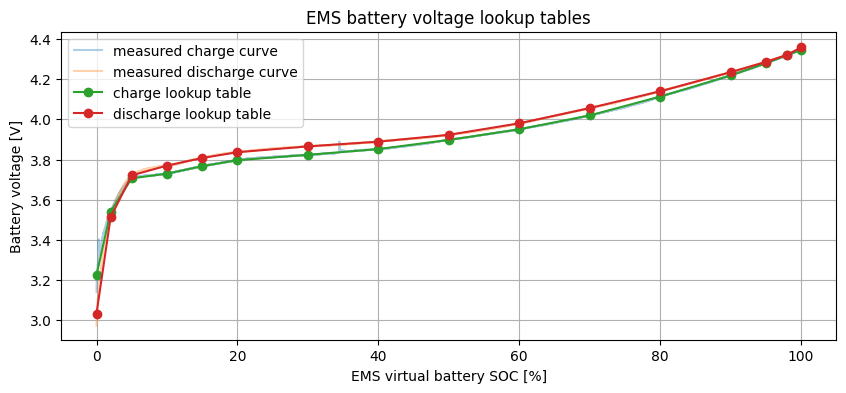

Copy these constants into the EMS battery model:

BATTERY_LOOKUP_SOC_PERCENT = (
    0.0,
    2.0,
    5.0,
    10.0,
    15.0,
    20.0,
    30.0,
    40.0,
    50.0,
    60.0,
    70.0,
    80.0,
    90.0,
    95.0,
    98.0,
    100.0,
)

BATTERY_CHARGE_VOLTAGE_LOOKUP_V = (
    3.2256,
    3.5411,
    3.7066,
    3.7299,
    3.7669,
    3.7970,
    3.8235,
    3.8521,
    3.8974,
    3.9507,
    4.0195,
    4.1133,
    4.2184,
    4.2793,
    4.3194,
    4.3463,
)

BATTERY_DISCHARGE_VOLTAGE_LOOKUP_V = (
    3.0332,
    3.5124,
    3.7214,
    3.7698,
    3.8077,
    3.8366,
    3.8655,
    3.8890,
    3.9229,
    3.9803,
    4.0560,
    4.1396,
    4.2348,
    4.2858,
    4.3210,
    4.3582,
)

Average voltage-to-SOC lookup table for EMS:

voltage_soc_curve: tuple[tuple[float, float], ...] = (
    (3.1294, 0.0),
    (3.5267, 2.0),
    (3.7140, 5.0),
    (3.7498, 10.0),
    (3.7873, 15.0),
    (3.8168, 20.0),
    (3.8445, 30.0),
    (3.8705, 40.0),
    (3.9101, 50.0),
    (3.9655, 60

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Find project root and load raw battery data
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

charge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_CHARGE_ina226_soc_log_20260420_180900.csv"
discharge_file = PROJECT_ROOT / "data/Battery_test/BATTERY_DISCHARGE_ina226_soc_log_20260421_095715.csv"

charge_raw = pd.read_csv(charge_file)
discharge_raw = pd.read_csv(discharge_file)

# ------------------------------------------------------------
# 2. Select active charge and discharge regions
# ------------------------------------------------------------

charge = charge_raw[charge_raw["current_mA"] > 50].copy()
discharge = discharge_raw[discharge_raw["current_mA"] < -50].copy()

charge["time_min"] = (charge["elapsed_s"] - charge["elapsed_s"].iloc[0]) / 60
discharge["time_min"] = (discharge["elapsed_s"] - discharge["elapsed_s"].iloc[0]) / 60

# ------------------------------------------------------------
# 3. Calculate discharge energy and EMS-scaled battery energy
# ------------------------------------------------------------

discharge["time_h"] = discharge["time_min"] / 60
discharge["dt_h"] = discharge["time_h"].diff().fillna(0)

discharge["discharge_current_A"] = -discharge["current_mA"] / 1000
discharge["discharge_power_W"] = (
    discharge["discharge_current_A"] * discharge["voltage_corrected_V"]
)

discharge["capacity_removed_Ah"] = (
    discharge["discharge_current_A"] * discharge["dt_h"]
).cumsum()

discharge["energy_removed_Wh"] = (
    discharge["discharge_power_W"] * discharge["dt_h"]
).cumsum()

MEASURED_BATTERY_ENERGY_WH = discharge["energy_removed_Wh"].iloc[-1]

EMS_BATTERY_CAPACITY_MILLIWATT_HOUR = 100.0
EMS_BATTERY_CAPACITY_WH = EMS_BATTERY_CAPACITY_MILLIWATT_HOUR / 1000

BATTERY_ENERGY_SCALE_FACTOR = (
    EMS_BATTERY_CAPACITY_WH / MEASURED_BATTERY_ENERGY_WH
)

discharge["ems_energy_removed_mWh"] = (
    discharge["energy_removed_Wh"] * BATTERY_ENERGY_SCALE_FACTOR * 1000
)

discharge["ems_energy_remaining_mWh"] = (
    EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    - discharge["ems_energy_removed_mWh"]
)

discharge["ems_energy_remaining_mWh"] = (
    discharge["ems_energy_remaining_mWh"].clip(0, EMS_BATTERY_CAPACITY_MILLIWATT_HOUR)
)

# ------------------------------------------------------------
# 4. Extract voltage lookup tables
# ------------------------------------------------------------

LOOKUP_SOC_POINTS = np.array(
    [0, 2, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80, 90, 95, 98, 100],
    dtype=float,
)


def require_columns(df, required_columns, name):
    missing = [column for column in required_columns if column not in df.columns]

    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


def prepare_charge_lookup_data(charge_df):
    curve = charge_df.copy()

    require_columns(
        curve,
        ["time_min", "current_mA", "voltage_corrected_V"],
        "charge",
    )

    curve["time_h"] = curve["time_min"] / 60.0
    curve["dt_h"] = curve["time_h"].diff().fillna(0).clip(lower=0)

    curve["charge_current_A"] = curve["current_mA"] / 1000.0
    curve["charge_power_W"] = (
        curve["charge_current_A"] * curve["voltage_corrected_V"]
    )

    curve["energy_added_Wh"] = (
        curve["charge_power_W"] * curve["dt_h"]
    ).cumsum()

    total_charge_energy_Wh = curve["energy_added_Wh"].iloc[-1]

    if total_charge_energy_Wh <= 0:
        raise ValueError("Total charge energy is zero or negative. Check charge data.")

    curve["ems_energy_added_mWh"] = (
        curve["energy_added_Wh"] / total_charge_energy_Wh
    ) * EMS_BATTERY_CAPACITY_MILLIWATT_HOUR

    curve["lookup_soc_percent"] = (
        100.0
        * curve["ems_energy_added_mWh"]
        / EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    ).clip(0, 100)

    return curve


def prepare_discharge_lookup_data(discharge_df):
    curve = discharge_df.copy()

    require_columns(
        curve,
        ["voltage_corrected_V", "ems_energy_remaining_mWh"],
        "discharge",
    )

    curve["lookup_soc_percent"] = (
        100.0
        * curve["ems_energy_remaining_mWh"]
        / EMS_BATTERY_CAPACITY_MILLIWATT_HOUR
    ).clip(0, 100)

    return curve


def make_smoothed_voltage_curve(curve_df, soc_column, voltage_column):
    curve = curve_df[[soc_column, voltage_column]].dropna().copy()

    curve[soc_column] = curve[soc_column].clip(0, 100)
    curve = curve.sort_values(soc_column)

    curve["soc_bin"] = curve[soc_column].round(2)

    grouped = (
        curve.groupby("soc_bin", as_index=False)[voltage_column]
        .median()
        .rename(
            columns={
                "soc_bin": "soc_percent",
                voltage_column: "voltage_V",
            }
        )
    )

    grouped["voltage_smooth_V"] = (
        grouped["voltage_V"]
        .rolling(window=31, center=True, min_periods=1)
        .median()
    )

    return grouped


def interpolate_voltage_lookup(smoothed_curve, target_soc_points):
    x = smoothed_curve["soc_percent"].to_numpy(dtype=float)
    y = smoothed_curve["voltage_smooth_V"].to_numpy(dtype=float)

    return np.interp(target_soc_points, x, y)


charge_lookup_data = prepare_charge_lookup_data(charge)
discharge_lookup_data = prepare_discharge_lookup_data(discharge)

charge_curve = make_smoothed_voltage_curve(
    charge_lookup_data,
    soc_column="lookup_soc_percent",
    voltage_column="voltage_corrected_V",
)

discharge_curve = make_smoothed_voltage_curve(
    discharge_lookup_data,
    soc_column="lookup_soc_percent",
    voltage_column="voltage_corrected_V",
)

charge_voltage_lookup = interpolate_voltage_lookup(
    charge_curve,
    LOOKUP_SOC_POINTS,
)

discharge_voltage_lookup = interpolate_voltage_lookup(
    discharge_curve,
    LOOKUP_SOC_POINTS,
)

battery_lookup_table = pd.DataFrame(
    {
        "soc_percent": LOOKUP_SOC_POINTS,
        "charge_voltage_V": charge_voltage_lookup,
        "discharge_voltage_V": discharge_voltage_lookup,
    }
)

display(battery_lookup_table)

# ------------------------------------------------------------
# 5. Plot lookup tables
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

plt.plot(
    charge_lookup_data["lookup_soc_percent"],
    charge_lookup_data["voltage_corrected_V"],
    alpha=0.35,
    label="measured charge curve",
)

plt.plot(
    discharge_lookup_data["lookup_soc_percent"],
    discharge_lookup_data["voltage_corrected_V"],
    alpha=0.35,
    label="measured discharge curve",
)

plt.plot(
    LOOKUP_SOC_POINTS,
    charge_voltage_lookup,
    "o-",
    label="charge lookup table",
)

plt.plot(
    LOOKUP_SOC_POINTS,
    discharge_voltage_lookup,
    "o-",
    label="discharge lookup table",
)

plt.title("EMS battery voltage lookup tables")
plt.xlabel("EMS virtual battery SOC [%]")
plt.ylabel("Battery voltage [V]")
plt.grid(True)
plt.legend()
plt.show()

# ------------------------------------------------------------
# 6. Print constants and save CSV
# ------------------------------------------------------------

print("Copy these constants into the EMS battery model:")
print()

print("BATTERY_LOOKUP_SOC_PERCENT = (")
for value in LOOKUP_SOC_POINTS:
    print(f"    {value:.1f},")
print(")")
print()

print("BATTERY_CHARGE_VOLTAGE_LOOKUP_V = (")
for value in charge_voltage_lookup:
    print(f"    {value:.4f},")
print(")")
print()

print("BATTERY_DISCHARGE_VOLTAGE_LOOKUP_V = (")
for value in discharge_voltage_lookup:
    print(f"    {value:.4f},")
print(")")
print()

# ------------------------------------------------------------
# 7. Average charge/discharge lookup and print as EMS tuple
# ------------------------------------------------------------

battery_lookup_table["average_voltage_V"] = (
    battery_lookup_table["charge_voltage_V"]
    + battery_lookup_table["discharge_voltage_V"]
) / 2.0

average_voltage_soc_curve = tuple(
    (round(voltage, 4), round(soc, 1))
    for voltage, soc in zip(
        battery_lookup_table["average_voltage_V"],
        battery_lookup_table["soc_percent"],
    )
)

print("Average voltage-to-SOC lookup table for EMS:")
print()
print("voltage_soc_curve: tuple[tuple[float, float], ...] = (")

for voltage, soc in average_voltage_soc_curve:
    print(f"    ({voltage:.4f}, {soc:.1f}),")

print(")")